Entrenando compuerta AND con SGD_lr_0.1...
Entrenando compuerta AND con SGD_lr_0.01...
Entrenando compuerta AND con Adam_lr_0.01...
Entrenando compuerta AND con Adam_lr_0.001...


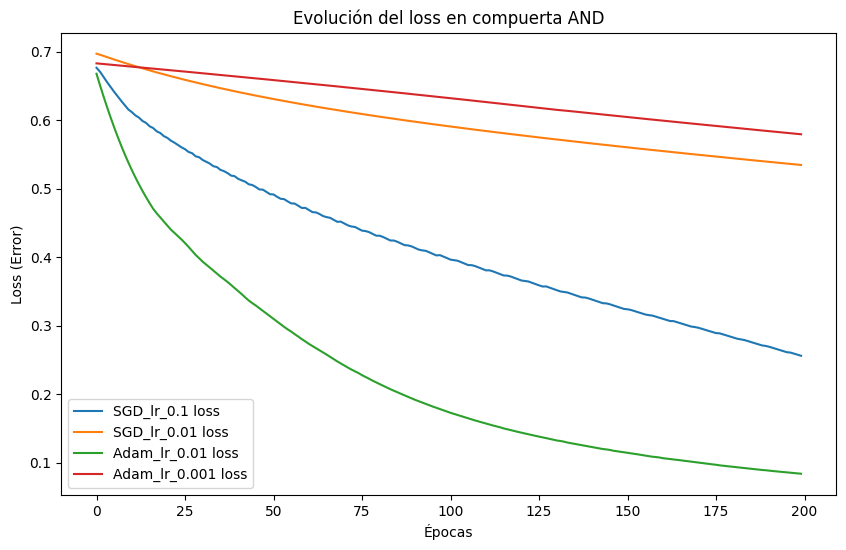


Resultados finales (Accuracy y Error):
SGD_lr_0.1: Accuracy=1.00, Error=0.2561
SGD_lr_0.01: Accuracy=0.75, Error=0.5346
Adam_lr_0.01: Accuracy=1.00, Error=0.0841
Adam_lr_0.001: Accuracy=0.75, Error=0.5794


In [6]:
# ============================================
# 1. Importar librerías necesarias
# ============================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================
# 2. Definir datos de la compuerta AND
# ============================================
# Entradas posibles: (0,0), (0,1), (1,0), (1,1)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
# Salida esperada para AND
y_and = np.array([0,0,0,1])

# ============================================
# 3. Definir el modelo
# ============================================
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# ============================================
# 4. Configurar optimizadores y tasas de aprendizaje
# ============================================
optimizers = {
    "SGD_lr_0.1": tf.keras.optimizers.SGD(learning_rate=0.1),
    "SGD_lr_0.01": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam_lr_0.01": tf.keras.optimizers.Adam(learning_rate=0.01),
    "Adam_lr_0.001": tf.keras.optimizers.Adam(learning_rate=0.001)
}

# ============================================
# 5. Entrenar y guardar resultados
# ============================================
histories = {}
results = {}

for name, opt in optimizers.items():
    model = build_model()
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    print(f"Entrenando compuerta AND con {name}...")
    history = model.fit(X, y_and, epochs=200, verbose=0)
    histories[name] = history
    # Guardamos métricas finales
    final_acc = history.history['accuracy'][-1]
    final_loss = history.history['loss'][-1]
    results[name] = (final_acc, final_loss)

# ============================================
# 6. Graficar el loss
# ============================================
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['loss'], label=f'{name} loss')
plt.legend()
plt.title("Evolución del loss en compuerta AND")
plt.xlabel("Épocas")
plt.ylabel("Loss (Error)")
plt.show()

# ============================================
# 7. Mostrar métricas finales por consola
# ============================================
print("\nResultados finales (Accuracy y Error):")
for name, (acc, loss) in results.items():
    print(f"{name}: Accuracy={acc:.2f}, Error={loss:.4f}")
